In [10]:
"""
Jupyter Notebook Visualization Tool for Uncertainty Quantification.

Usage in a notebook:
    from notebook_vis import show_notebook_report
    show_notebook_report(limit=3)
"""

import sqlite3
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd

# Configuration
DB_PATH = "db/results.sqlite"

def get_db_connection():
    if not os.path.exists(DB_PATH):
        print(f"Error: Database not found at {DB_PATH}")
        return None
    try:
        conn = sqlite3.connect(DB_PATH)
        conn.row_factory = sqlite3.Row
        return conn
    except sqlite3.Error as e:
        print(f"Database error: {e}")
        return None

def fetch_data(limit=5):
    conn = get_db_connection()
    if not conn:
        return []
    
    results = []
    try:
        cur = conn.cursor()
        query = """
        SELECT 
            r.result_id, r.question_text, r.predicted_answer, r.gold_answer,
            r.is_correct, r.uq_avg_entropy, r.uq_mech_score, m.model_name
        FROM Results r
        JOIN Models m ON r.model_id = m.model_id
        ORDER BY r.result_id DESC
        LIMIT ?
        """
        cur.execute(query, (limit,))
        rows = cur.fetchall()
        
        for row in rows:
            res = dict(row)
            t_query = """
            SELECT position, token_text, entropy, logit_gap, mechanistic_score 
            FROM Token_Metrics WHERE result_id = ? ORDER BY position ASC
            """
            cur.execute(t_query, (row['result_id'],))
            res['tokens'] = [dict(t) for t in cur.fetchall()]
            results.append(res)
    finally:
        conn.close()
    return results

def calculate_composite_uncertainty(res):
    """
    Calculates a 'Composite Uncertainty' score by combining normalized metrics.
    """
    if not res['tokens']: return np.array([]), np.array([]), np.array([]), np.array([])

    entropies = np.array([t['entropy'] for t in res['tokens']])
    mech = np.array([t['mechanistic_score'] for t in res['tokens']])
    gaps = np.array([t['logit_gap'] for t in res['tokens']])

    def z_score(arr):
        if len(arr) < 2 or np.std(arr) == 0: return np.zeros_like(arr)
        return (arr - np.mean(arr)) / np.std(arr)

    z_ent = z_score(entropies)
    z_mech = z_score(mech)
    z_gap = z_score(-gaps) 

    composite = (z_ent + z_mech + z_gap) / 3.0
    return composite, z_ent, z_mech, z_gap

def analyze_mechanistic_flatness(res):
    """
    Analyzes the mechanistic score for flatness/variance to help debug configuration issues.
    """
    mech_scores = np.array([t['mechanistic_score'] for t in res['tokens']])
    
    if len(mech_scores) == 0:
        return

    std_dev = np.std(mech_scores)
    span = np.max(mech_scores) - np.min(mech_scores)
    
    print(f"  MECHANISTIC SCORE DIAGNOSTICS:")
    print(f"    • Mean: {np.mean(mech_scores):.6f}")
    print(f"    • Std Dev: {std_dev:.6f}")
    print(f"    • Range: {np.min(mech_scores):.6f} to {np.max(mech_scores):.6f} (Span: {span:.6f})")
    
    if std_dev < 1e-5:
        print("    ⚠️  ALERT: Score is essentially FLAT (constant).")
        print("       Possible causes: ")
        print("       1. Entropy neurons config file not found or empty.")
        print("       2. Activations were not captured (check HFAgent/ActivationMonitor).")
        print("       3. Model architecture mismatch with config indices.")
    else:
        print("    ✅  Score varies across tokens.")
    print("-" * 40)

def analyze_high_uncertainty_spans(res, composite_scores):
    tokens = [t['token_text'].replace('Ġ', ' ').replace('Ċ', ' ') for t in res['tokens']]
    # Handle case where composite scores might be all zeros (if input metrics were flat)
    if np.all(composite_scores == 0):
        return []
        
    high_uncertainty_indices = np.where(composite_scores > 2.0)[0]
    
    if len(high_uncertainty_indices) == 0:
        return []

    spans = []
    if len(high_uncertainty_indices) > 0:
        current_span = [high_uncertainty_indices[0]]
        for i in range(1, len(high_uncertainty_indices)):
            idx = high_uncertainty_indices[i]
            prev = high_uncertainty_indices[i-1]
            if idx <= prev + 2:
                current_span.append(idx)
            else:
                spans.append(current_span)
                current_span = [idx]
        spans.append(current_span)

    results = []
    for span in spans:
        span_text = "".join([tokens[i] for i in span])
        avg_score = np.mean(composite_scores[span])
        results.append((span_text, avg_score))
    
    return results

def plot_single_trace(res):
    tokens = [t['token_text'] for t in res['tokens']]
    entropies = [t['entropy'] for t in res['tokens']]
    mech_scores = [t['mechanistic_score'] for t in res['tokens']]
    logit_gaps = [t['logit_gap'] for t in res['tokens']]
    positions = range(len(tokens))
    
    if not tokens: return

    composite, z_ent, z_mech, z_gap = calculate_composite_uncertainty(res)

    fig, (ax1, ax_corr) = plt.subplots(1, 2, figsize=(24, 6), gridspec_kw={'width_ratios': [3, 1]})
    
    color_ent = 'tab:red'
    ax1.set_xlabel('Generated Tokens')
    ax1.set_ylabel('Entropy / Composite', color=color_ent, fontweight='bold')
    l1, = ax1.plot(positions, entropies, color=color_ent, alpha=0.6, label='Entropy (Raw)')
    l2, = ax1.plot(positions, composite, color='black', linewidth=2, linestyle='-', label='Composite Z-Score')
    ax1.tick_params(axis='y', labelcolor=color_ent)
    
    ax2 = ax1.twinx()
    color_mech = 'tab:blue'
    ax2.set_ylabel('Mechanistic Score', color=color_mech, fontweight='bold')
    
    # Check for flatness before plotting to avoid scaling issues
    if np.std(mech_scores) < 1e-6:
        # Plot as a flat line but set fixed limits
        l3, = ax2.plot(positions, mech_scores, color=color_mech, alpha=0.6, linestyle='--', label='Mech Score (Flat)')
        ax2.set_ylim(-1, 1) # Standard tanh range
    else:
        l3, = ax2.plot(positions, mech_scores, color=color_mech, alpha=0.6, linestyle='--', label='Mech Score')
    
    ax2.tick_params(axis='y', labelcolor=color_mech)
    
    lines = [l1, l2, l3]
    ax1.legend(lines, [l.get_label() for l in lines], loc='upper left')

    ax1.set_xticks(positions)
    ax1.set_xticklabels(tokens, rotation=45, ha='right', fontsize=8, fontfamily='monospace')
    ax1.grid(True, linestyle=':', alpha=0.5)

    status = "✅ CORRECT" if res['is_correct'] else "❌ INCORRECT"
    ax1.set_title(f"{status} | {res['model_name']} | Uncertainty Trace")

    df_corr = pd.DataFrame({
        'Entropy': entropies,
        'Mech Score': mech_scores,
        'Logit Gap': logit_gaps,
        'Composite': composite
    })
    # Handle constant columns (NaN correlation)
    corr = df_corr.corr().fillna(0)
    
    cax = ax_corr.matshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
    fig.colorbar(cax, ax=ax_corr, fraction=0.046, pad=0.04)
    
    ax_corr.set_xticks(range(len(corr.columns)))
    ax_corr.set_yticks(range(len(corr.columns)))
    ax_corr.set_xticklabels(corr.columns, rotation=45, ha='left')
    ax_corr.set_yticklabels(corr.columns)
    ax_corr.set_title("Metric Correlations", pad=20)
    
    for i in range(len(corr.columns)):
        for j in range(len(corr.columns)):
            text = ax_corr.text(j, i, f"{corr.iloc[i, j]:.2f}",
                           ha="center", va="center", color="black")

    plt.tight_layout()
    plt.show()

    print(f"HIGH UNCERTAINTY SPANS (> 2 SDs from mean composite score):")
    spans = analyze_high_uncertainty_spans(res, composite)
    if spans:
        for text, score in spans:
            print(f"  • \"{text.strip()}\" (Z-Score: {score:.2f})")
    else:
        print("  (None detected)")
    print("-" * 80)

def show_notebook_report(limit=5):
    data = fetch_data(limit)
    if not data:
        print("No data found.")
        return

    for res in data:
        print("=" * 100)
        print(f"QUESTION: {res['question_text']}")
        print(f"PREDICTION: {res['predicted_answer']} (Gold: {res['gold_answer']})")
        print("-" * 100)
        # Add flatness analysis before plotting
        analyze_mechanistic_flatness(res)
        plot_single_trace(res)

QUESTION: Betty is saving money for a new wallet which costs $100. Betty has only half of the money she needs. Her parents decided to give her $15 for that purpose, and her grandparents twice as much as her parents. How much more money does Betty need to buy the wallet?
PREDICTION: 5 (Gold: 5)
----------------------------------------------------------------------------------------------------
  MECHANISTIC SCORE DIAGNOSTICS:
    • Mean: 0.249240
    • Std Dev: 0.223792
    • Range: -0.108154 to 0.798340 (Span: 0.906494)
    ✅  Score varies across tokens.
----------------------------------------


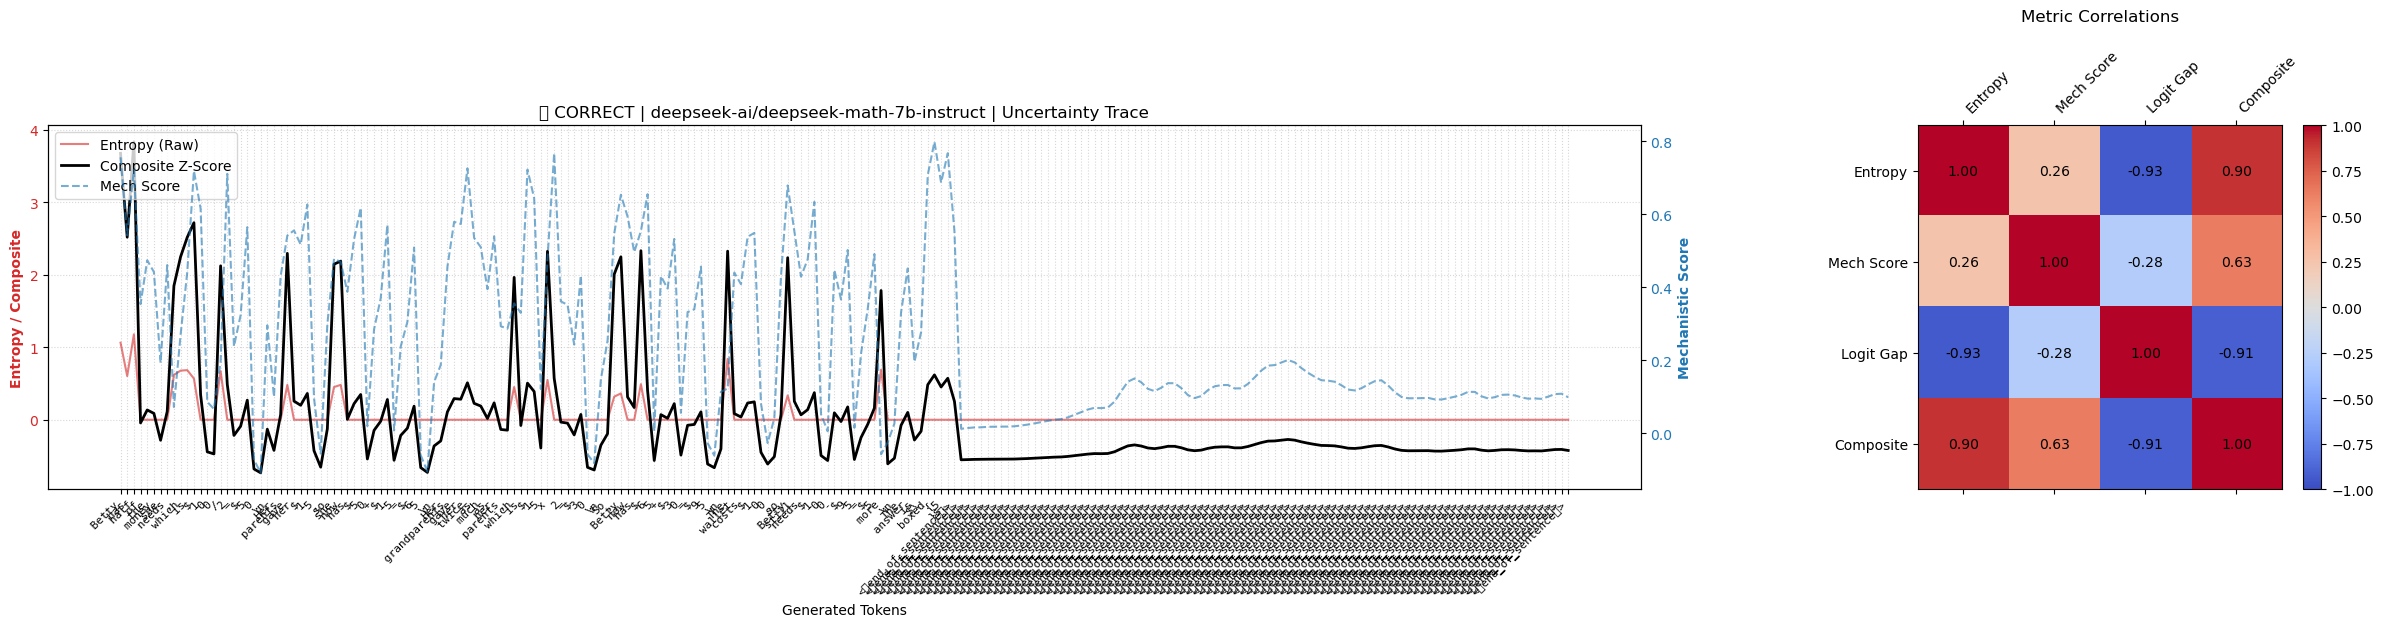

HIGH UNCERTAINTY SPANS (> 2 SDs from mean composite score):
  • "Betty has half" (Z-Score: 3.34)
  • "which is $" (Z-Score: 2.49)
  • "/" (Z-Score: 2.12)
  • "gave" (Z-Score: 2.29)
  • "she now" (Z-Score: 2.17)
  • "x" (Z-Score: 2.32)
  • ", Betty" (Z-Score: 2.13)
  • "$" (Z-Score: 2.33)
  • "The" (Z-Score: 2.32)
  • "Betty" (Z-Score: 2.23)
--------------------------------------------------------------------------------
QUESTION: Weng earns $12 an hour for babysitting. Yesterday, she just did 50 minutes of babysitting. How much did she earn?
PREDICTION: 10 (Gold: 10)
----------------------------------------------------------------------------------------------------
  MECHANISTIC SCORE DIAGNOSTICS:
    • Mean: 0.272821
    • Std Dev: 0.204573
    • Range: -0.111755 to 0.844238 (Span: 0.955994)
    ✅  Score varies across tokens.
----------------------------------------


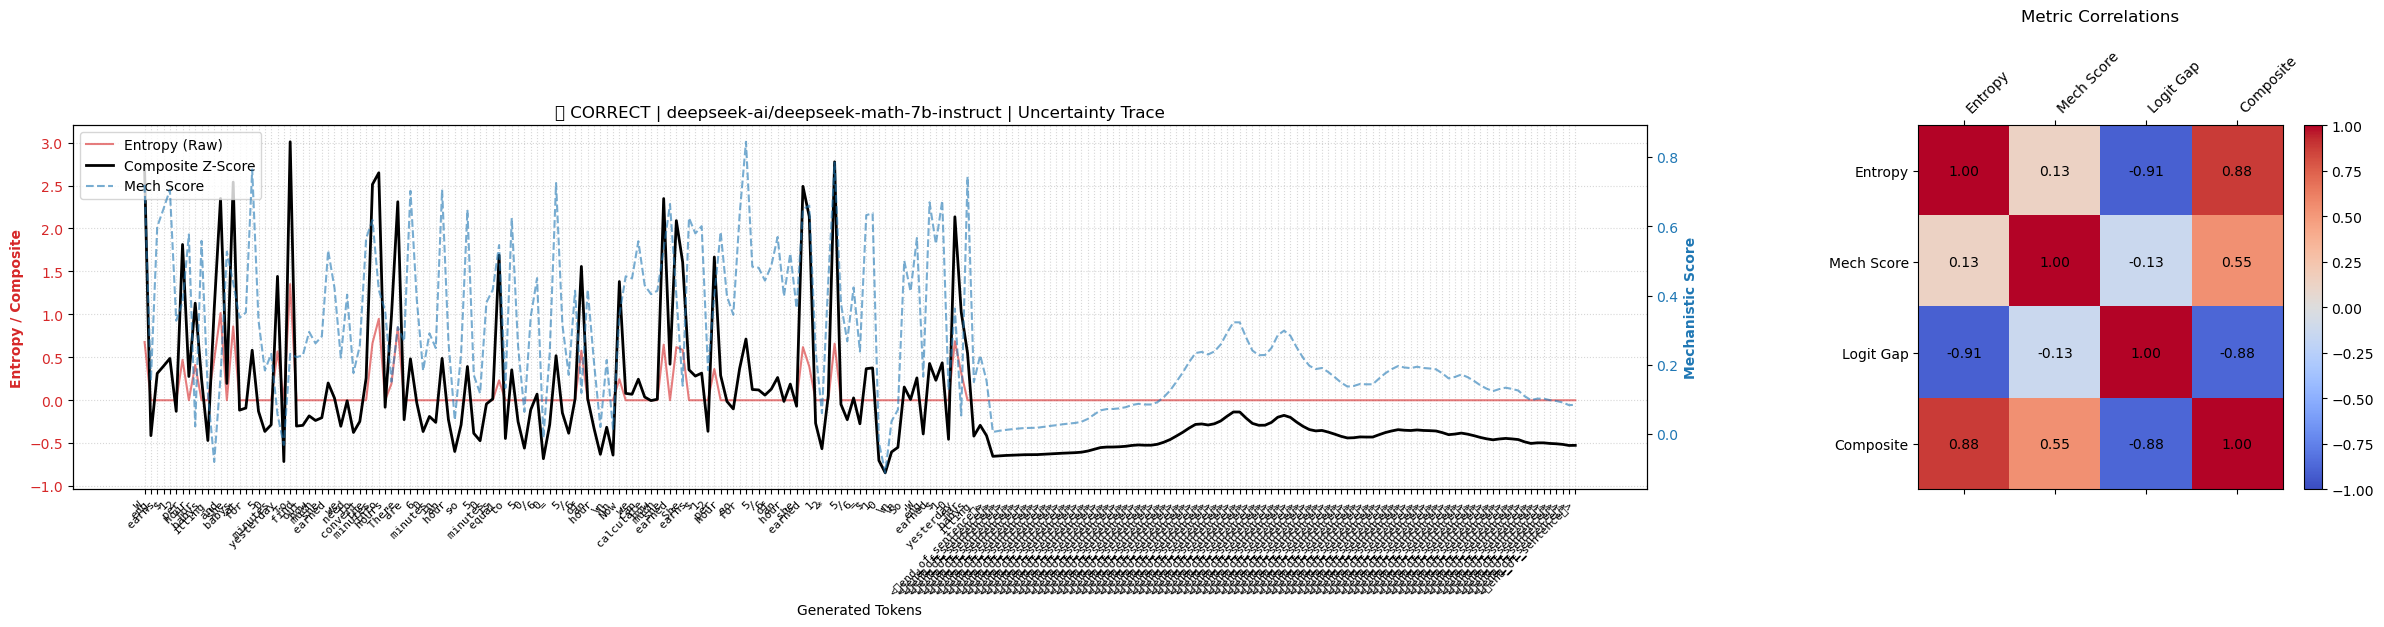

HIGH UNCERTAINTY SPANS (> 2 SDs from mean composite score):
  • "W" (Z-Score: 2.70)
  • "and babys" (Z-Score: 2.44)
  • "To" (Z-Score: 3.01)
  • "minutes into" (Z-Score: 2.58)
  • "There" (Z-Score: 2.31)
  • "she." (Z-Score: 2.22)
  • "earned" (Z-Score: 2.31)
  • "" (Z-Score: 2.78)
  • "yesterday" (Z-Score: 2.14)
--------------------------------------------------------------------------------
QUESTION: Natalia sold clips to 48 of her friends in April, and then she sold half as many clips in May. How many clips did Natalia sell altogether in April and May?
PREDICTION: 72 (Gold: 72)
----------------------------------------------------------------------------------------------------
  MECHANISTIC SCORE DIAGNOSTICS:
    • Mean: 0.366836
    • Std Dev: 0.253889
    • Range: -0.101624 to 0.834961 (Span: 0.936584)
    ✅  Score varies across tokens.
----------------------------------------


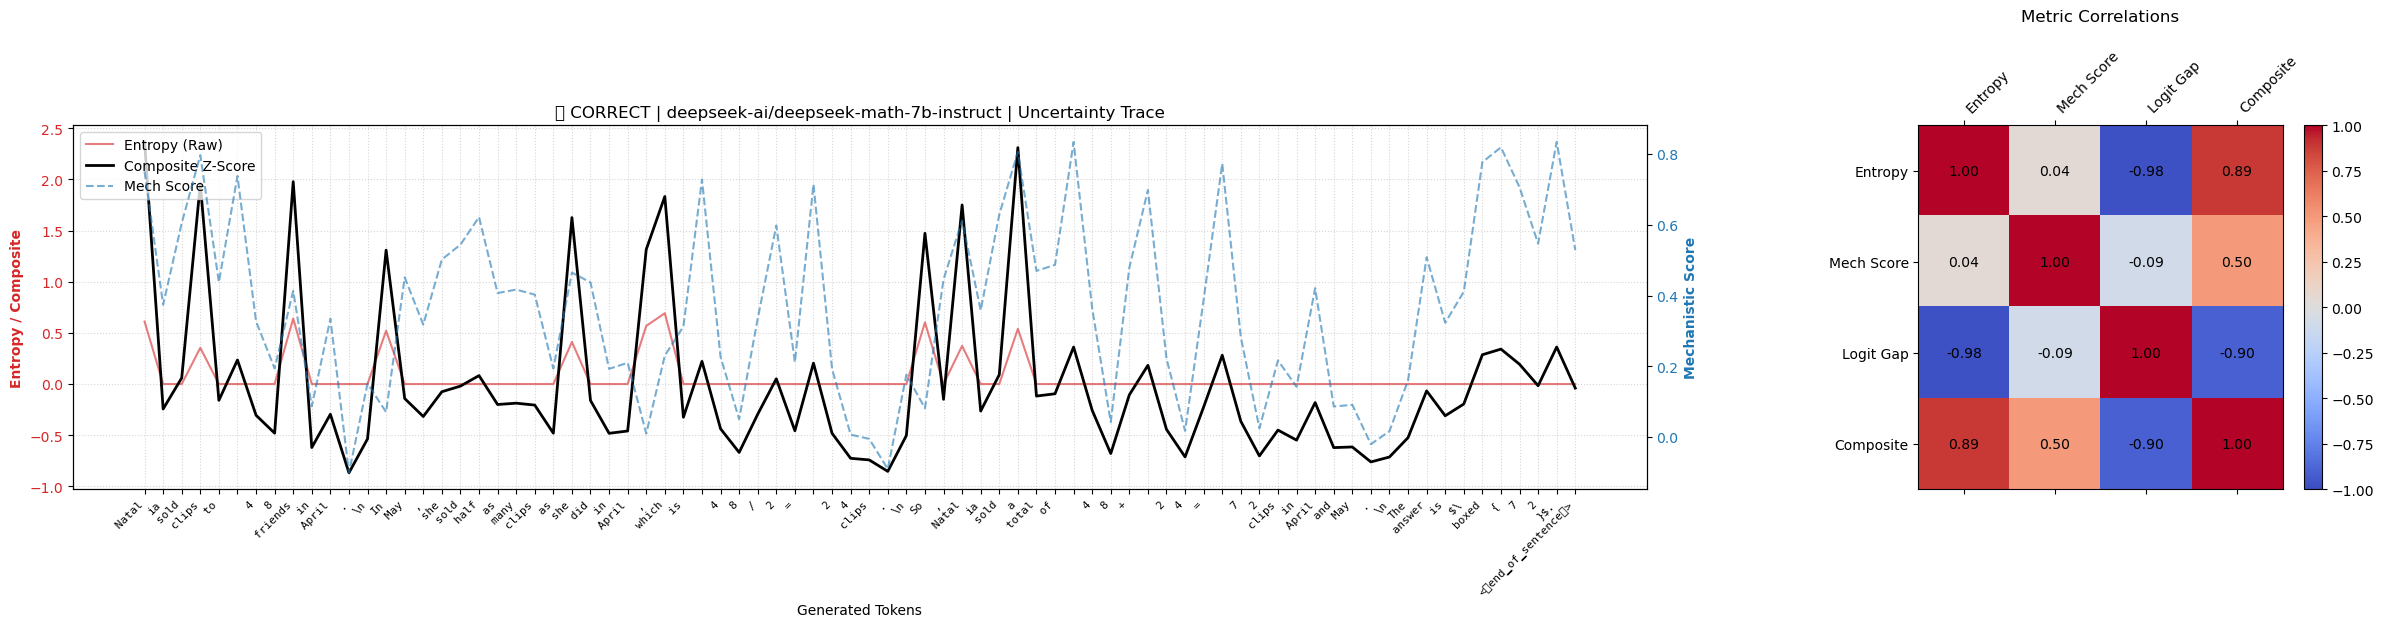

HIGH UNCERTAINTY SPANS (> 2 SDs from mean composite score):
  • "Natal" (Z-Score: 2.37)
  • "a" (Z-Score: 2.31)
--------------------------------------------------------------------------------
QUESTION: Natalia sold clips to 48 of her friends in April, and then she sold half as many clips in May. How many clips did Natalia sell altogether in April and May?
PREDICTION: 72 (Gold: 72)
----------------------------------------------------------------------------------------------------
  MECHANISTIC SCORE DIAGNOSTICS:
    • Mean: 0.267561
    • Std Dev: 0.244541
    • Range: -0.087585 to 0.840332 (Span: 0.927917)
    ✅  Score varies across tokens.
----------------------------------------


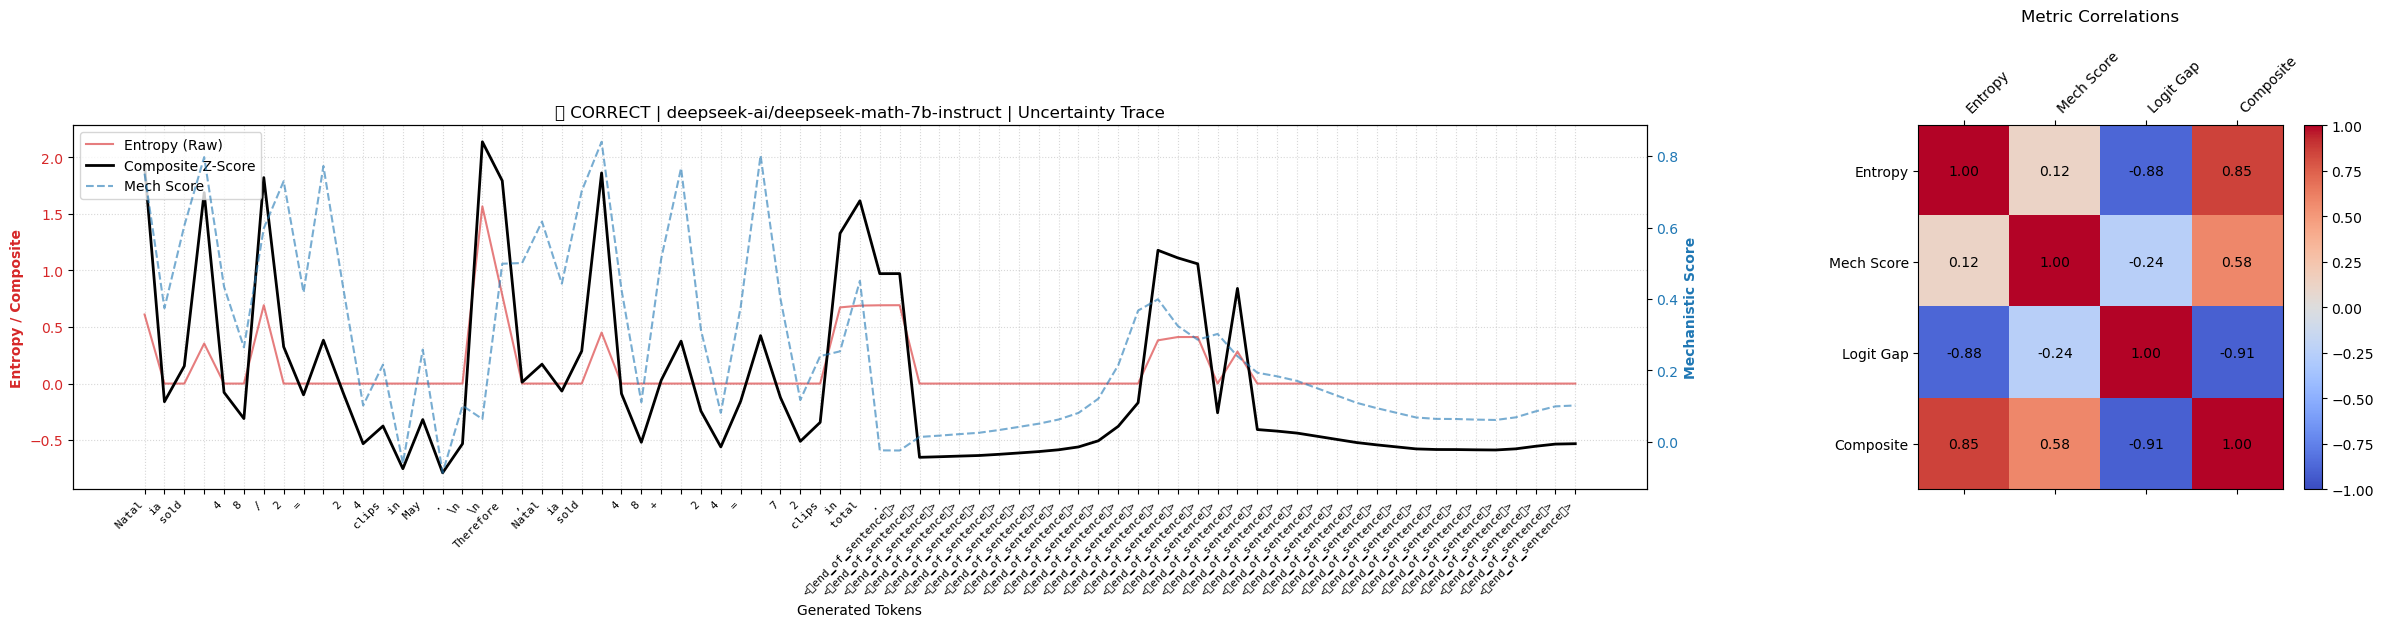

HIGH UNCERTAINTY SPANS (> 2 SDs from mean composite score):
  • "\n" (Z-Score: 2.14)
--------------------------------------------------------------------------------
QUESTION: Natalia sold clips to 48 of her friends in April, and then she sold half as many clips in May. How many clips did Natalia sell altogether in April and May?
PREDICTION: 72 (Gold: 72)
----------------------------------------------------------------------------------------------------
  MECHANISTIC SCORE DIAGNOSTICS:
    • Mean: 0.000000
    • Std Dev: 0.000000
    • Range: 0.000000 to 0.000000 (Span: 0.000000)
    ⚠️  ALERT: Score is essentially FLAT (constant).
       Possible causes: 
       1. Entropy neurons config file not found or empty.
       2. Activations were not captured (check HFAgent/ActivationMonitor).
       3. Model architecture mismatch with config indices.
----------------------------------------


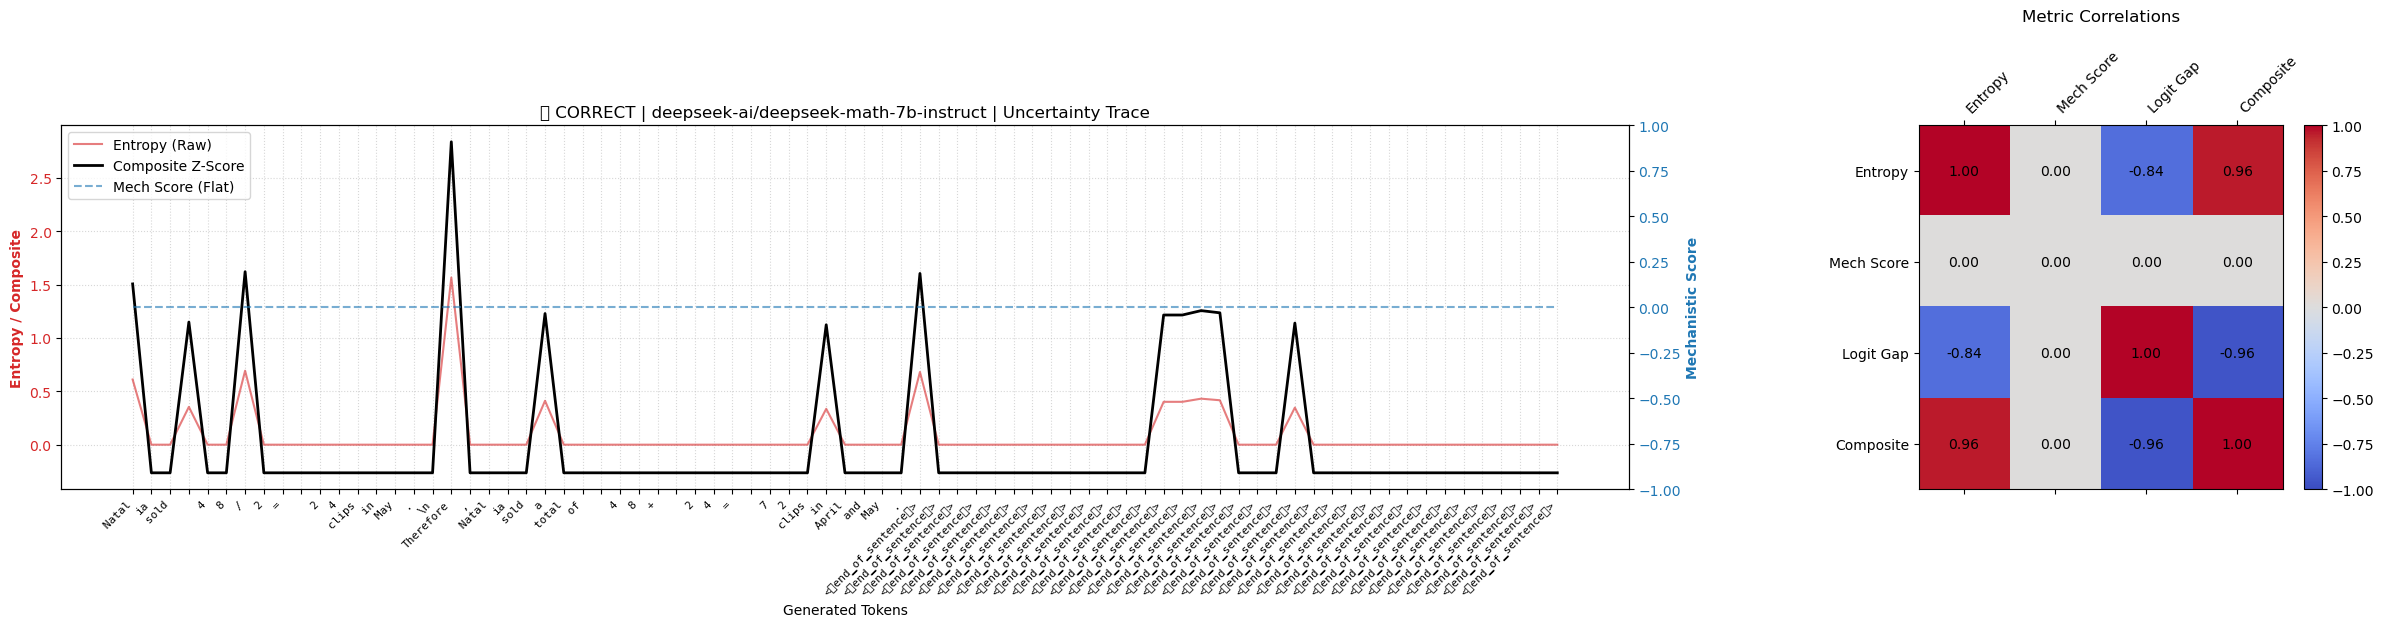

HIGH UNCERTAINTY SPANS (> 2 SDs from mean composite score):
  • "Therefore" (Z-Score: 2.84)
--------------------------------------------------------------------------------


In [11]:
import warnings 
warnings.filterwarnings("ignore")
show_notebook_report()